In [2]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math
from matplotlib.gridspec import GridSpec
path_google = 'G:/Shared drives/'
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")
import normPlot
import pandas as pd


In [3]:
hd = "hd191201"    

obs = sorted([f.name for f in obs_folder.glob(f"{hd}*.s")])

print(f"Found {len(obs)} observations for {hd}:")
for f in obs:
    print(f)
print(obs)

filename1 = obs[0]
filename2 = obs[1]

spec1 = pol.read_spectrum(obs_folder / filename1)
spec1 = spec1.merge_orders(mode="trim")
spec2 = pol.read_spectrum(obs_folder / filename2)
spec2 = spec2.merge_orders(mode="trim")

label1 = filename1.replace("_rn.s", "")
label2 = filename2.replace("_rn.s", "")
spec = spec1
name = filename1

Found 2 observations for hd191201:
hd191201_E_1308737pn_rn.s
hd191201_E_1720107pnm_rn.s
['hd191201_E_1308737pn_rn.s', 'hd191201_E_1720107pnm_rn.s']


In [3]:
print(spec.wl[0])
print(spec.wl[-1])

369.6786
1048.0886


Make LSD line profiles

In [ ]:
VALD_file_name = 'LongList_T30000G375.dat'
file_output = 'T30000_depth0.01.mask'
mask = pol.make_mask(VALD_file_name, outMaskName = file_output, 
                     depthCutoff = 0.02, atomsOnly = True)

velrange = 600.0

excluded_regions = (
    pol.get_Balmer_regions_default(velrange)
    + pol.get_telluric_regions_default()
)

mask_clean = mask.clean(excluded_regions)
mask_clean.save(r"T30000G375_depth0.02_clean.mask")

''' T30000G375_depth0.01.mask and T30000G375_depth0.02.mask are from LongList_T30000G375.dat, 
which required Lande factor when generating VALD mask on VALD website.
T30000G375_depth0.01.mask has only too few of lines in its model. '''


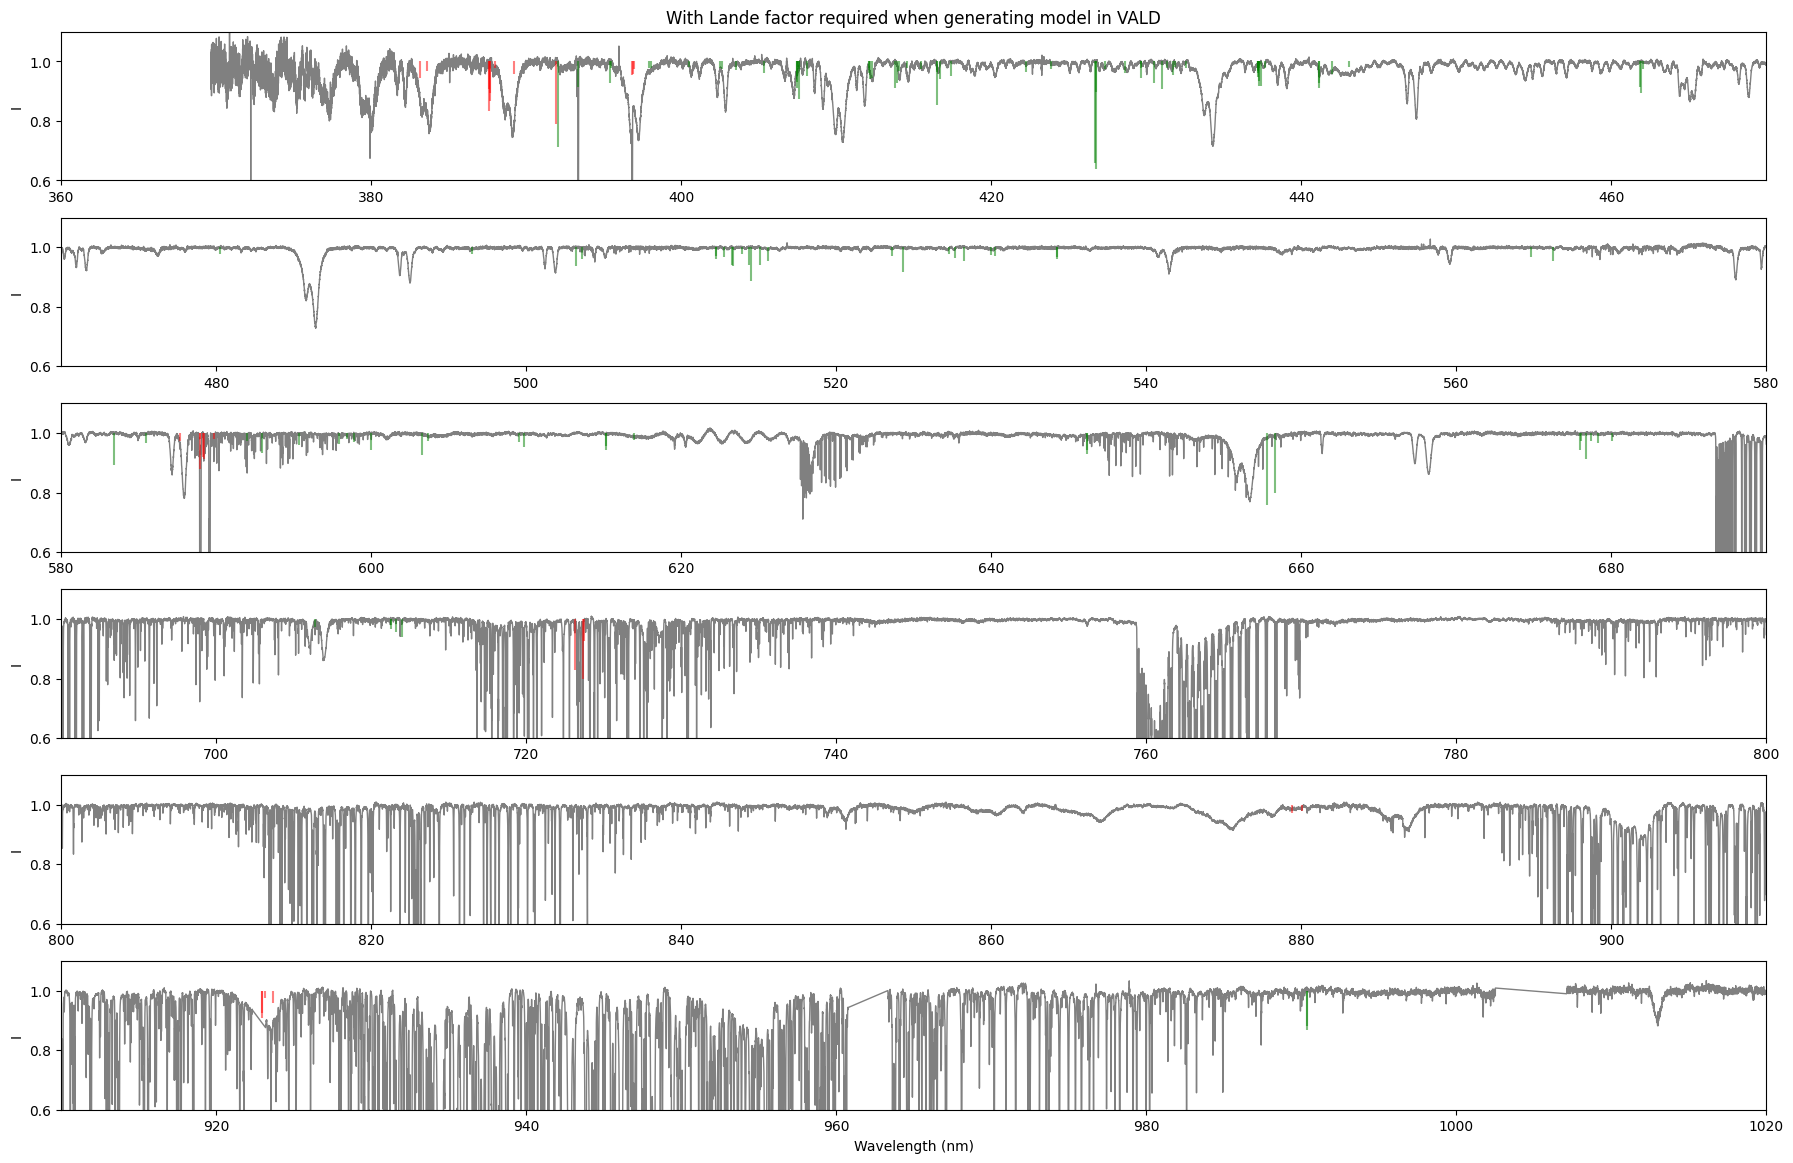

number of lines are 148


In [13]:
mask_clean = pol.read_mask("T30000G375_depth0.02_clean.mask")

windows_mask = [
    (360, 470),
    (470, 580),
    (580, 690),
    (690, 800),
    (800, 910),
    (910, 1020),
    (1020, 1100)
]


fig, axes = plt.subplots(6, 1, figsize=(22, 14))

for ax, (xmin, xmax) in zip(axes, windows_mask):

    ax.plot(spec1.wl, spec1.specI, color="0.5", lw=1)

    used = np.where(mask_clean.iuse == 1)
    unused = np.where(mask_clean.iuse == 0)

    ax.vlines(mask_clean.wl[used], 1-mask_clean.depth[used], 1,
              color="g", alpha=0.5)

    ax.vlines(mask_clean.wl[unused], 1-mask_clean.depth[unused], 1,
              color="r", alpha=0.5)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0.6, 1.1)
    ax.set_ylabel("I")

axes[-1].set_xlabel("Wavelength (nm)")
axes[0].set_title("With Lande factor required when generating model in VALD")
plt.subplots_adjust(hspace=0.25)
plt.show()
print("number of lines are {}".format(len(mask_clean.wl)))

In [ ]:
VALD_file_name = 'LongListT30000G375_noLF.dat'
file_output = 'Trial2_depth0.02.mask'
mask = pol.make_mask(VALD_file_name, outMaskName = file_output, 
                     depthCutoff = 0.02, atomsOnly = True)

velrange = 600.0

excluded_regions = (
    pol.get_Balmer_regions_default(velrange)
    + pol.get_telluric_regions_default()
)

mask_clean = mask.clean(excluded_regions)
mask_clean.save(r"Trial2_depth0.02_clean.mask")




missing Lande factors for 132 lines (skipped) from:
[np.str_('He 2'), np.str_('O 2')]
skipped all lines for species:
[np.str_('H 1')]


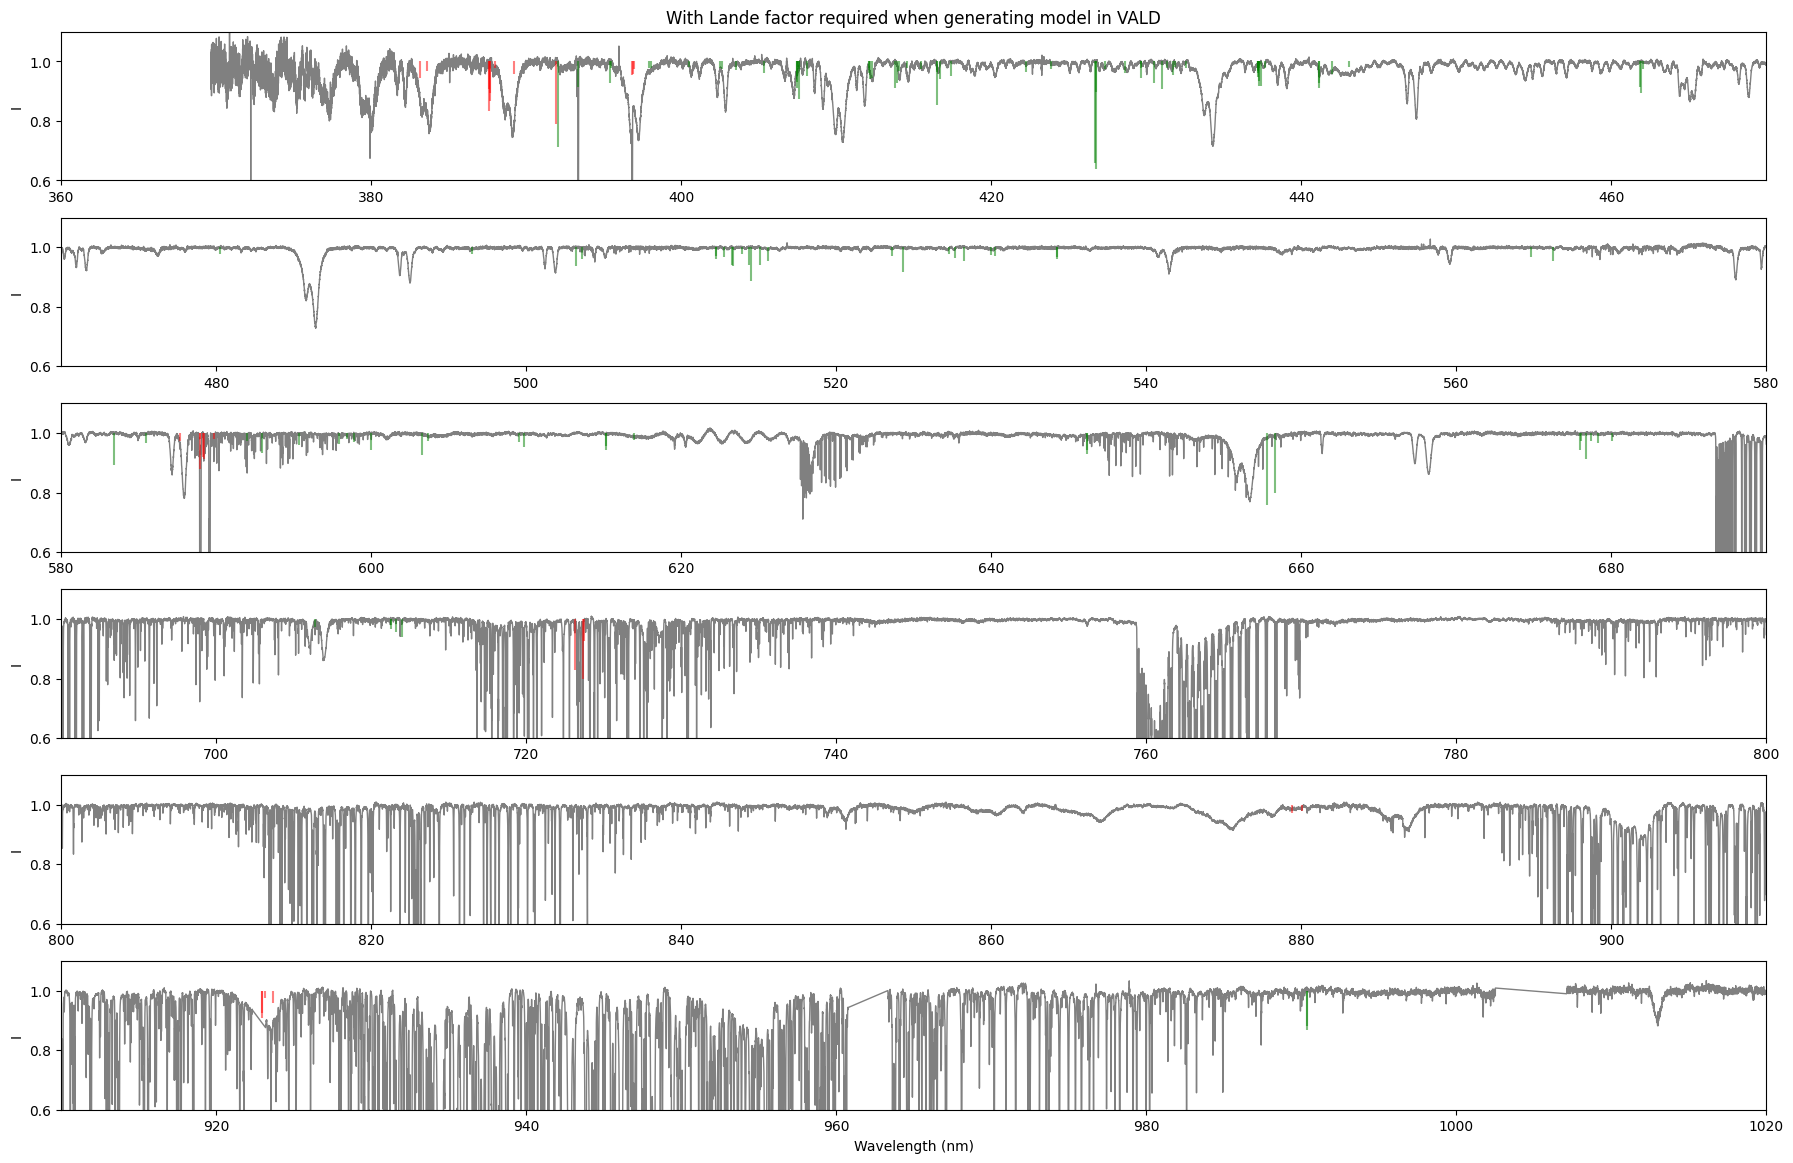

number of lines are 148


In [ ]:
mask_clean2 = pol.read_mask("T30000G375_depth0.02_clean.mask")

windows_mask = [
    (360, 470),
    (470, 580),
    (580, 690),
    (690, 800),
    (800, 910),
    (910, 1020),
    (1020, 1100)
]


fig, axes = plt.subplots(6, 1, figsize=(22, 14))

for ax, (xmin, xmax) in zip(axes, windows_mask):

    ax.plot(spec1.wl, spec1.specI, color="0.5", lw=1)

    used = np.where(mask_clean2.iuse == 1)s
    unused = np.where(mask_clean2.iuse == 0)

    ax.vlines(mask_clean2.wl[used], 1-mask_clean2.depth[used], 1,
              color="g", alpha=0.5)

    ax.vlines(mask_clean2.wl[unused], 1-mask_clean2.depth[unused], 1,
              color="r", alpha=0.5)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0.6, 1.1)
    ax.set_ylabel("I")

axes[-1].set_xlabel("Wavelength (nm)")
axes[0].set_title("With Lande factor required when generating model in VALD")
plt.subplots_adjust(hspace=0.25)
plt.show()
print("number of lines are {}".format(len(mask_clean2.wl)))